# Clasificación Temporal de Condiciones Meteorológicas mediante LSTM y GRU

## Laboratorio 3 – Redes Neuronales Recurrentes

**Objetivo:** desarrollar y comparar modelos LSTM y GRU capaces de clasificar condiciones meteorológicas a partir de secuencias temporales.

El proyecto aplica técnicas de optimización, regularización y buenas prácticas de entrenamiento, evaluando los modelos mediante métricas de clasificación, gráficas de aprendizaje y matrices de confusión.

## 1. Configuración del entorno

En esta sección se importan las librerías necesarias y se establece una semilla aleatoria para favorecer la reproducibilidad de los experimentos.

In [11]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Dispositivo utilizado: {device}")

Dispositivo utilizado: cpu


## 2. Carga y exploración del dataset

Se utiliza el conjunto de datos meteorológicos Jena Climate, que contiene mediciones registradas cada 10 minutos.

El conjunto incluye variables relacionadas con temperatura, presión atmosférica, humedad, vapor de agua y viento. Estas características permiten representar la evolución temporal de las condiciones meteorológicas.

In [12]:
DATASET_PATH = "Dataset/jena_climate/jena_climate_2009_2016.csv"

df = pd.read_csv(DATASET_PATH)

print("Dimensiones del dataset:", df.shape)

df.head()

Dimensiones del dataset: (420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


## 3. Preparación y limpieza de los datos

Primero se transforma la columna de fecha a un formato temporal. Posteriormente se ordenan los registros cronológicamente y se revisan los valores anómalos.

El dataset utiliza el valor `-9999` como indicador de mediciones inválidas en determinadas variables. Estos valores se reemplazan por valores nulos y posteriormente se eliminan las filas afectadas.

Este procedimiento evita que valores fuera del rango físico esperado afecten la normalización y el entrenamiento de la red neuronal.

In [13]:
# Conversión de fecha
df["Date Time"] = pd.to_datetime(
    df["Date Time"],
    format="%d.%m.%Y %H:%M:%S"
)

# Orden cronológico
df = df.sort_values("Date Time").reset_index(drop=True)

# Reemplazar valores inválidos
df = df.replace(-9999, np.nan)

# Eliminar registros con valores faltantes
df = df.dropna().reset_index(drop=True)

print("Dimensiones después de la limpieza:", df.shape)
print("Valores nulos restantes:", df.isnull().sum().sum())

Dimensiones después de la limpieza: (420531, 15)
Valores nulos restantes: 0


## 4. Selección de características

Se seleccionan variables representativas de diferentes aspectos de las condiciones meteorológicas:

- temperatura;
- humedad relativa;
- presión atmosférica;
- temperatura de rocío;
- velocidad del viento;
- velocidad máxima del viento;
- dirección del viento.

Estas variables permiten proporcionar al modelo información térmica, atmosférica y relacionada con el viento.

In [14]:
features = [
    "p (mbar)",
    "T (degC)",
    "Tdew (degC)",
    "rh (%)",
    "wv (m/s)",
    "max. wv (m/s)",
    "wd (deg)"
]

data = df[["Date Time"] + features].copy()

print("Características utilizadas:")
print(features)

data.head()

Características utilizadas:
['p (mbar)', 'T (degC)', 'Tdew (degC)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']


,Date Time,p (mbar),T (degC),Tdew (degC),rh (%),wv (m/s),max. wv (m/s),wd (deg)
0,2009-01-01 00:10:00,996.52,-8.02,-8.90,93.3,1.03,1.75,152.3
1,2009-01-01 00:20:00,996.57,-8.41,-9.28,93.4,0.72,1.50,136.1
2,2009-01-01 00:30:00,996.53,-8.51,-9.31,93.9,0.19,0.63,171.6
3,2009-01-01 00:40:00,996.51,-8.31,-9.07,94.2,0.34,0.50,198.0
4,2009-01-01 00:50:00,996.51,-8.27,-9.04,94.1,0.32,0.63,214.3


## 5. Creación de la variable objetivo

El problema se plantea como una tarea de clasificación temporal de tres clases.

A partir de la temperatura futura se establecen tres categorías:

- **Frío:** temperaturas bajas.
- **Moderado:** temperaturas intermedias.
- **Cálido:** temperaturas altas.

Los límites entre categorías se calculan utilizando terciles de la temperatura del conjunto de entrenamiento. De esta forma se evita utilizar información del conjunto de prueba para definir las clases y se reduce el riesgo de fuga de información.

In [15]:
# División temporal del dataset
n = len(data)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = data.iloc[:train_end].copy()
val_df = data.iloc[train_end:val_end].copy()
test_df = data.iloc[val_end:].copy()

# Umbrales calculados SOLO con entrenamiento
q1 = train_df["T (degC)"].quantile(1/3)
q2 = train_df["T (degC)"].quantile(2/3)

print(f"Umbral Frío/Moderado: {q1:.2f} °C")
print(f"Umbral Moderado/Cálido: {q2:.2f} °C")

Umbral Frío/Moderado: 5.20 °C
Umbral Moderado/Cálido: 13.24 °C


In [16]:
def crear_clases_temperatura(df, q1, q2):
    temperatura = df["T (degC)"]

    return np.select(
        [
            temperatura <= q1,
            temperatura <= q2
        ],
        [
            0,
            1
        ],
        default=2
    )


train_df["target"] = crear_clases_temperatura(train_df, q1, q2)
val_df["target"] = crear_clases_temperatura(val_df, q1, q2)
test_df["target"] = crear_clases_temperatura(test_df, q1, q2)

class_names = ["Frío", "Moderado", "Cálido"]

print("Distribución de clases - entrenamiento:")
print(train_df["target"].value_counts().sort_index())

print("\nDistribución de clases - validación:")
print(val_df["target"].value_counts().sort_index())

print("\nDistribución de clases - prueba:")
print(test_df["target"].value_counts().sort_index())

Distribución de clases - entrenamiento:
target
0    98162
1    98164
2    98045
Name: count, dtype: int64

Distribución de clases - validación:
target
0    17184
1    20352
2    25544
Name: count, dtype: int64

Distribución de clases - prueba:
target
0    20668
1    22661
2    19751
Name: count, dtype: int64


## 6. Distribución de las clases

Antes de entrenar los modelos se analiza la distribución de las tres categorías. Esta comprobación permite verificar si existe un desbalance importante entre las clases.

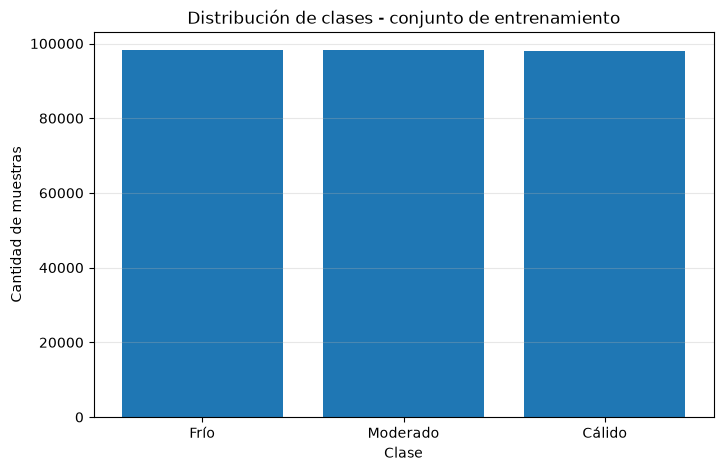

In [17]:
counts = train_df["target"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(class_names, counts.values)

plt.title("Distribución de clases - conjunto de entrenamiento")
plt.xlabel("Clase")
plt.ylabel("Cantidad de muestras")
plt.grid(axis="y", alpha=0.3)

plt.show()

## 7. Normalización de las características

Las características presentan escalas y unidades diferentes. Por ejemplo, la presión atmosférica se expresa en mbar, la humedad en porcentaje y la velocidad del viento en m/s.

Se utiliza `StandardScaler` para estandarizar las variables.

El escalador se ajusta exclusivamente con el conjunto de entrenamiento y posteriormente se aplica a validación y prueba. Esto evita introducir información de los conjuntos posteriores durante el entrenamiento.

In [18]:
scaler = StandardScaler()

X_train = scaler.fit_transform(train_df[features])
X_val = scaler.transform(val_df[features])
X_test = scaler.transform(test_df[features])

y_train = train_df["target"].values
y_val = val_df["target"].values
y_test = test_df["target"].values

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (294371, 7)
X_val: (63080, 7)
X_test: (63080, 7)


## 8. Construcción de secuencias temporales

Para que LSTM y GRU puedan aprovechar la información temporal, cada muestra está formada por las últimas 24 horas de observaciones.

Debido a que existen seis mediciones por hora, una ventana de 24 horas contiene:

**24 × 6 = 144 observaciones.**

El objetivo corresponde a la clase meteorológica asociada a la siguiente observación.

In [19]:
SEQ_LEN = 144

def create_sequences(X, y, seq_len):
    X_seq = []
    y_seq = []

    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i + seq_len])
        y_seq.append(y[i + seq_len])

    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.int64)


X_train_seq, y_train_seq = create_sequences(X_train, y_train, SEQ_LEN)
X_val_seq, y_val_seq = create_sequences(X_val, y_val, SEQ_LEN)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, SEQ_LEN)

print("Train:", X_train_seq.shape, y_train_seq.shape)
print("Validation:", X_val_seq.shape, y_val_seq.shape)
print("Test:", X_test_seq.shape, y_test_seq.shape)

Train: (294227, 144, 7) (294227,)
Validation: (62936, 144, 7) (62936,)
Test: (62936, 144, 7) (62936,)


## 9. Preparación de los DataLoader

Se convierten las secuencias a tensores de PyTorch y se utilizan `DataLoader` para procesar los datos por lotes durante el entrenamiento.

In [20]:
class WeatherDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 64

train_dataset = WeatherDataset(X_train_seq, y_train_seq)
val_dataset = WeatherDataset(X_val_seq, y_val_seq)
test_dataset = WeatherDataset(X_test_seq, y_test_seq)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("DataLoaders preparados correctamente.")

DataLoaders preparados correctamente.


## 10. Modelos LSTM y GRU

Se implementan dos arquitecturas de redes neuronales recurrentes: LSTM (Long Short-Term Memory) y GRU (Gated Recurrent Unit).

Ambos modelos reciben las mismas secuencias temporales y utilizan una arquitectura equivalente para realizar una comparación justa.

La entrada corresponde a 144 observaciones temporales con 7 características meteorológicas. La salida contiene tres clases: Frío, Moderado y Cálido.

Para reducir el sobreajuste se incorpora Dropout después de la capa recurrente.

In [21]:
class LSTMModel(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size=64,
        num_layers=2,
        num_classes=3,
        dropout=0.3
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        output, (hidden, cell) = self.lstm(x)

        last_hidden = hidden[-1]

        x = self.dropout(last_hidden)

        return self.fc(x)


class GRUModel(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size=64,
        num_layers=2,
        num_classes=3,
        dropout=0.3
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        output, hidden = self.gru(x)

        last_hidden = hidden[-1]

        x = self.dropout(last_hidden)

        return self.fc(x)

## 11. Configuración de los modelos

Ambos modelos utilizan la misma configuración para facilitar la comparación:

- 7 características de entrada.
- 64 unidades ocultas.
- 2 capas recurrentes.
- Dropout de 0.3.
- 3 clases de salida.

La única diferencia entre ambos modelos es la unidad recurrente utilizada: LSTM o GRU.

In [22]:
INPUT_SIZE = len(features)
HIDDEN_SIZE = 64
NUM_LAYERS = 2
NUM_CLASSES = 3
DROPOUT = 0.3

lstm_model = LSTMModel(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT
).to(device)

gru_model = GRUModel(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT
).to(device)

print("LSTM:")
print(lstm_model)

print("\nGRU:")
print(gru_model)

LSTM:
LSTMModel(
  (lstm): LSTM(7, 64, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=3, bias=True)
)

GRU:
GRUModel(
  (gru): GRU(7, 64, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=3, bias=True)
)


## 12. Complejidad de los modelos

Se calcula el número de parámetros entrenables de cada arquitectura. Esto permite comparar no solamente el rendimiento predictivo, sino también la complejidad de los modelos.

In [23]:
def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


print(
    f"Parámetros LSTM: "
    f"{count_parameters(lstm_model):,}"
)

print(
    f"Parámetros GRU: "
    f"{count_parameters(gru_model):,}"
)

Parámetros LSTM: 52,163
Parámetros GRU: 39,171


## 13. Entrenamiento

Para el entrenamiento se utiliza el optimizador Adam y Cross Entropy Loss, apropiado para un problema de clasificación multiclase.

Además, se incorporan técnicas de optimización y regularización:

- Adam como optimizador.
- Learning Rate Scheduler para reducir progresivamente la tasa de aprendizaje.
- Weight Decay como regularización L2.
- Dropout para reducir el sobreajuste.
- Early Stopping para detener el entrenamiento cuando la pérdida de validación deja de mejorar.
- Guardado del mejor modelo según la pérdida de validación.

Estas técnicas permiten mejorar la estabilidad del entrenamiento y reducir el riesgo de sobreajuste.

In [24]:
def train_model(
    model,
    train_loader,
    val_loader,
    epochs=20,
    learning_rate=0.001,
    weight_decay=1e-4,
    patience=4
):
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "lr": []
    }

    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0

    for epoch in range(epochs):

        # -------------------------
        # Entrenamiento
        # -------------------------
        model.train()

        total_train_loss = 0
        train_correct = 0
        train_total = 0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            loss.backward()

            # Evita gradientes excesivamente grandes
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()

            total_train_loss += loss.item() * X_batch.size(0)

            predictions = outputs.argmax(dim=1)

            train_correct += (
                predictions == y_batch
            ).sum().item()

            train_total += y_batch.size(0)

        train_loss = total_train_loss / train_total
        train_acc = train_correct / train_total

        # -------------------------
        # Validación
        # -------------------------
        model.eval()

        total_val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                outputs = model(X_batch)

                loss = criterion(outputs, y_batch)

                total_val_loss += (
                    loss.item() * X_batch.size(0)
                )

                predictions = outputs.argmax(dim=1)

                val_correct += (
                    predictions == y_batch
                ).sum().item()

                val_total += y_batch.size(0)

        val_loss = total_val_loss / val_total
        val_acc = val_correct / val_total

        # Scheduler
        scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"LR: {current_lr:.6f}"
        )

        # -------------------------
        # Early Stopping
        # -------------------------
        if val_loss < best_val_loss:

            best_val_loss = val_loss

            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

            patience_counter = 0

        else:

            patience_counter += 1

            if patience_counter >= patience:

                print(
                    f"\nEarly Stopping en epoch "
                    f"{epoch + 1}"
                )

                break

    # Restaurar mejor modelo
    if best_state is not None:
        model.load_state_dict(best_state)

    return history

## 14. Entrenamiento del modelo LSTM

Se entrena el modelo LSTM utilizando exactamente el mismo conjunto de entrenamiento y validación que posteriormente se utilizará para GRU.

De esta manera, la comparación entre ambos modelos se realiza bajo las mismas condiciones experimentales.

In [25]:
history_lstm = train_model(
    lstm_model,
    train_loader,
    val_loader,
    epochs=20,
    learning_rate=0.001,
    weight_decay=1e-4,
    patience=4
)

Epoch 01/20 | Train Loss: 0.0799 | Val Loss: 0.0522 | Train Acc: 0.9675 | Val Acc: 0.9791 | LR: 0.001000
Epoch 02/20 | Train Loss: 0.0469 | Val Loss: 0.0390 | Train Acc: 0.9807 | Val Acc: 0.9864 | LR: 0.001000
Epoch 03/20 | Train Loss: 0.0419 | Val Loss: 0.0414 | Train Acc: 0.9834 | Val Acc: 0.9840 | LR: 0.001000
Epoch 04/20 | Train Loss: 0.0394 | Val Loss: 0.0391 | Train Acc: 0.9841 | Val Acc: 0.9852 | LR: 0.001000
Epoch 05/20 | Train Loss: 0.0373 | Val Loss: 0.0353 | Train Acc: 0.9851 | Val Acc: 0.9864 | LR: 0.001000
Epoch 06/20 | Train Loss: 0.0371 | Val Loss: 0.0357 | Train Acc: 0.9853 | Val Acc: 0.9869 | LR: 0.001000
Epoch 07/20 | Train Loss: 0.0360 | Val Loss: 0.0379 | Train Acc: 0.9858 | Val Acc: 0.9847 | LR: 0.001000
Epoch 08/20 | Train Loss: 0.0357 | Val Loss: 0.0394 | Train Acc: 0.9860 | Val Acc: 0.9850 | LR: 0.000500
Epoch 09/20 | Train Loss: 0.0323 | Val Loss: 0.0327 | Train Acc: 0.9875 | Val Acc: 0.9876 | LR: 0.000500
Epoch 10/20 | Train Loss: 0.0320 | Val Loss: 0.0351 | T

## 15. Entrenamiento del modelo GRU

Se entrena el modelo GRU utilizando la misma configuración experimental empleada para LSTM.

In [26]:
history_gru = train_model(
    gru_model,
    train_loader,
    val_loader,
    epochs=20,
    learning_rate=0.001,
    weight_decay=1e-4,
    patience=4
)

Epoch 01/20 | Train Loss: 0.0732 | Val Loss: 0.0424 | Train Acc: 0.9699 | Val Acc: 0.9847 | LR: 0.001000
Epoch 02/20 | Train Loss: 0.0450 | Val Loss: 0.0482 | Train Acc: 0.9816 | Val Acc: 0.9796 | LR: 0.001000
Epoch 03/20 | Train Loss: 0.0400 | Val Loss: 0.0400 | Train Acc: 0.9838 | Val Acc: 0.9848 | LR: 0.001000
Epoch 04/20 | Train Loss: 0.0382 | Val Loss: 0.0371 | Train Acc: 0.9847 | Val Acc: 0.9859 | LR: 0.001000
Epoch 05/20 | Train Loss: 0.0371 | Val Loss: 0.0339 | Train Acc: 0.9852 | Val Acc: 0.9880 | LR: 0.001000
Epoch 06/20 | Train Loss: 0.0361 | Val Loss: 0.0350 | Train Acc: 0.9856 | Val Acc: 0.9867 | LR: 0.001000
Epoch 07/20 | Train Loss: 0.0361 | Val Loss: 0.0433 | Train Acc: 0.9855 | Val Acc: 0.9821 | LR: 0.001000
Epoch 08/20 | Train Loss: 0.0353 | Val Loss: 0.0329 | Train Acc: 0.9858 | Val Acc: 0.9883 | LR: 0.001000
Epoch 09/20 | Train Loss: 0.0349 | Val Loss: 0.0378 | Train Acc: 0.9862 | Val Acc: 0.9849 | LR: 0.001000
Epoch 10/20 | Train Loss: 0.0347 | Val Loss: 0.0336 | T

## 16. Evolución del entrenamiento del LSTM

Se visualiza la evolución de la pérdida y la exactitud durante el entrenamiento. Estas gráficas permiten analizar la estabilidad del proceso de aprendizaje y detectar posibles signos de sobreajuste.

La selección del modelo final se realiza utilizando la menor pérdida de validación.

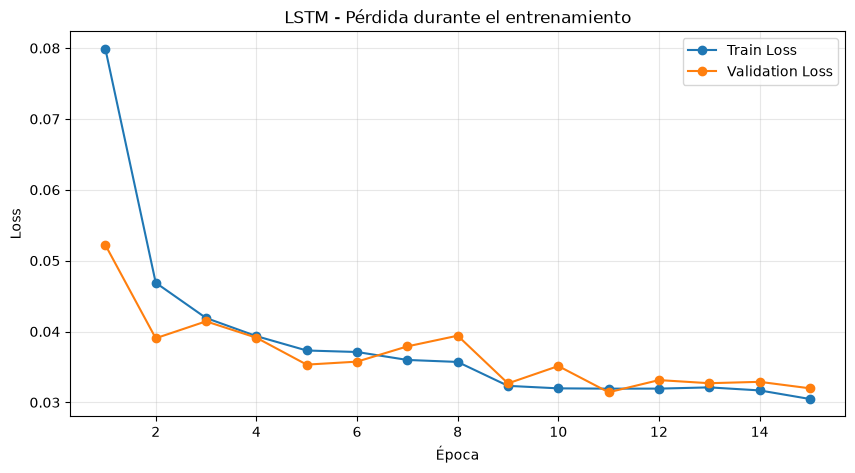

In [27]:
epochs_lstm = range(1, len(history_lstm["train_loss"]) + 1)

plt.figure(figsize=(10, 5))

plt.plot(
    epochs_lstm,
    history_lstm["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    epochs_lstm,
    history_lstm["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("LSTM - Pérdida durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

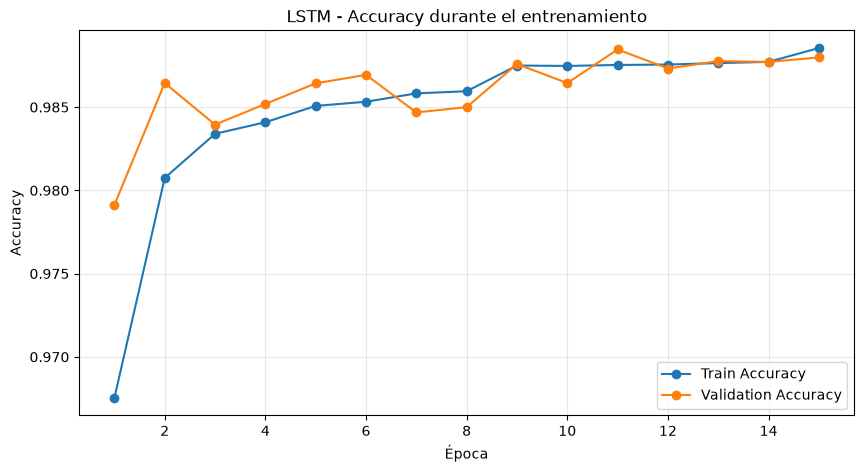

In [28]:
plt.figure(figsize=(10, 5))

plt.plot(
    epochs_lstm,
    history_lstm["train_acc"],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    epochs_lstm,
    history_lstm["val_acc"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("LSTM - Accuracy durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 17. Evolución de la tasa de aprendizaje

Se analiza la evolución del learning rate durante el entrenamiento. El scheduler reduce automáticamente la tasa de aprendizaje cuando la pérdida de validación deja de mejorar, permitiendo realizar ajustes más pequeños durante las etapas finales del aprendizaje.

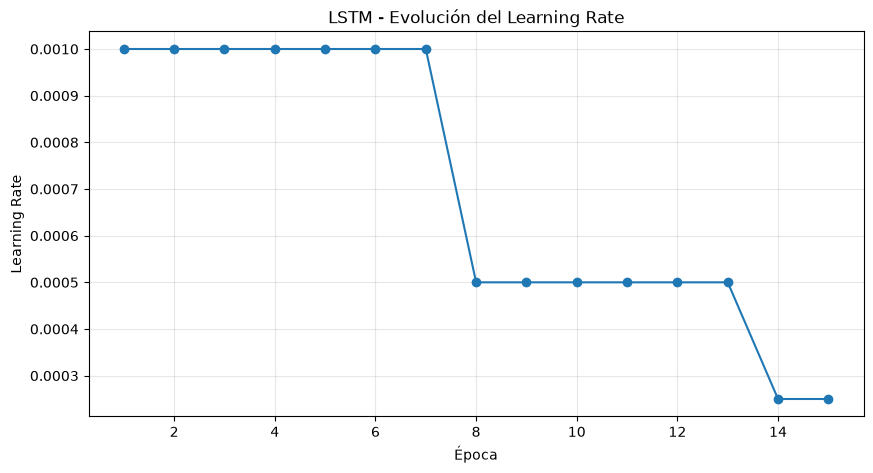

In [29]:
plt.figure(figsize=(10, 5))

plt.plot(
    epochs_lstm,
    history_lstm["lr"],
    marker="o"
)

plt.title("LSTM - Evolución del Learning Rate")
plt.xlabel("Época")
plt.ylabel("Learning Rate")
plt.grid(alpha=0.3)

plt.show()

## 18. Evaluación del LSTM sobre el conjunto de prueba

Una vez finalizado el entrenamiento, se evalúa el modelo utilizando exclusivamente el conjunto de prueba.

Se calculan Accuracy, Precision, Recall y F1-score para obtener una evaluación completa del rendimiento de clasificación.

In [30]:
def get_predictions(model, loader):

    model.eval()

    all_predictions = []
    all_targets = []

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)

            outputs = model(X_batch)

            predictions = outputs.argmax(dim=1)

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_targets.extend(
                y_batch.numpy()
            )

    return np.array(all_targets), np.array(all_predictions)


y_true_lstm, y_pred_lstm = get_predictions(
    lstm_model,
    test_loader
)

accuracy_lstm = accuracy_score(
    y_true_lstm,
    y_pred_lstm
)

precision_lstm = precision_score(
    y_true_lstm,
    y_pred_lstm,
    average="weighted",
    zero_division=0
)

recall_lstm = recall_score(
    y_true_lstm,
    y_pred_lstm,
    average="weighted",
    zero_division=0
)

f1_lstm = f1_score(
    y_true_lstm,
    y_pred_lstm,
    average="weighted",
    zero_division=0
)

print(f"Accuracy : {accuracy_lstm:.4f}")
print(f"Precision: {precision_lstm:.4f}")
print(f"Recall   : {recall_lstm:.4f}")
print(f"F1-score : {f1_lstm:.4f}")

Accuracy : 0.9889
Precision: 0.9889
Recall   : 0.9889
F1-score : 0.9889


## 19. Reporte de clasificación del LSTM

Además de las métricas globales, se analiza el rendimiento individual para cada una de las tres clases meteorológicas.

Esto permite determinar si el modelo presenta dificultades específicas para identificar condiciones frías, moderadas o cálidas.

In [31]:
print(
    classification_report(
        y_true_lstm,
        y_pred_lstm,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        Frío     0.9908    0.9889    0.9898     20668
    Moderado     0.9854    0.9837    0.9845     22517
      Cálido     0.9911    0.9950    0.9930     19751

    accuracy                         0.9889     62936
   macro avg     0.9891    0.9892    0.9891     62936
weighted avg     0.9889    0.9889    0.9889     62936



## 20. Matriz de confusión del LSTM

La matriz de confusión permite observar la cantidad de predicciones correctas e incorrectas para cada clase.

La diagonal principal representa las clasificaciones correctas, mientras que los valores fuera de la diagonal representan las confusiones entre categorías.

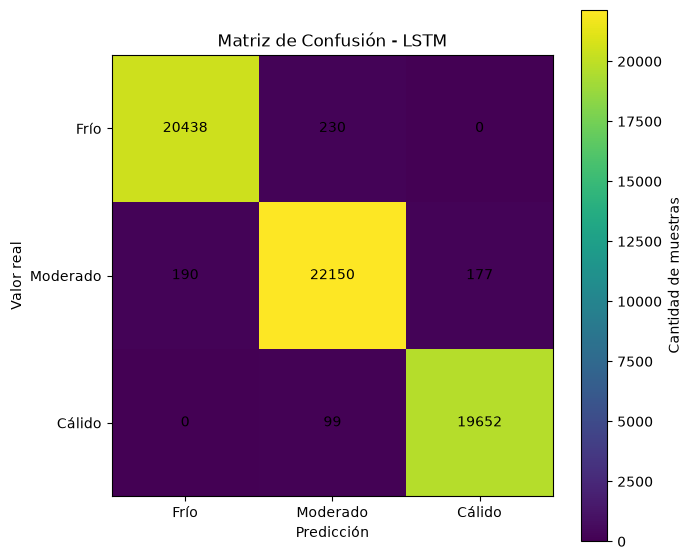

In [32]:
cm_lstm = confusion_matrix(
    y_true_lstm,
    y_pred_lstm
)

plt.figure(figsize=(7, 6))

plt.imshow(cm_lstm)

plt.title("Matriz de Confusión - LSTM")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.xticks(
    range(len(class_names)),
    class_names
)

plt.yticks(
    range(len(class_names)),
    class_names
)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            cm_lstm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar(label="Cantidad de muestras")

plt.tight_layout()
plt.show()

## 21. Evolución del entrenamiento del GRU

Se visualiza la evolución de la pérdida y la exactitud durante el entrenamiento del modelo GRU. Estas gráficas permiten analizar su comportamiento y compararlo posteriormente con LSTM.

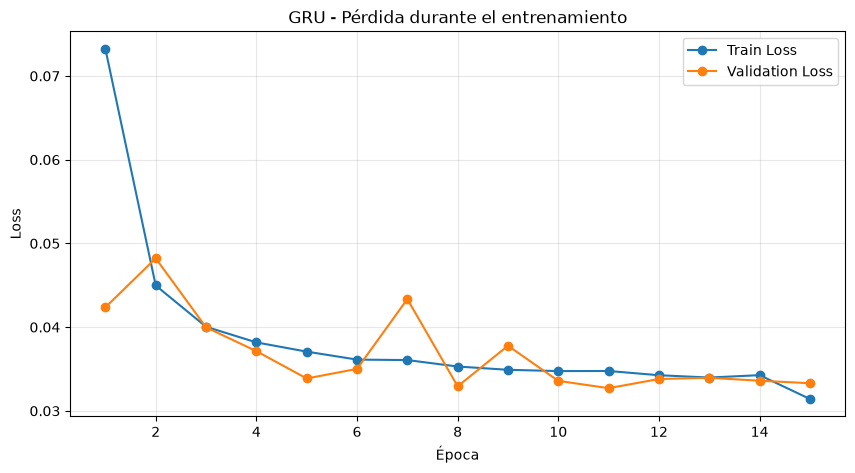

In [33]:
epochs_gru = range(1, len(history_gru["train_loss"]) + 1)

plt.figure(figsize=(10, 5))

plt.plot(
    epochs_gru,
    history_gru["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    epochs_gru,
    history_gru["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("GRU - Pérdida durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

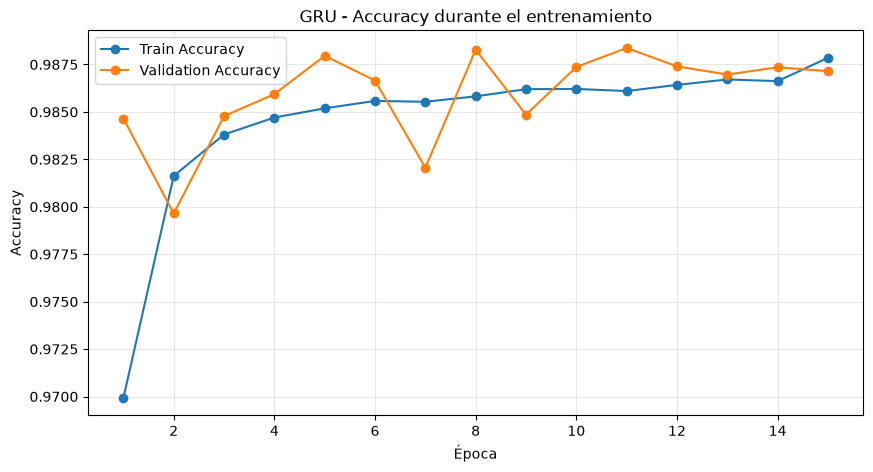

In [34]:
plt.figure(figsize=(10, 5))

plt.plot(
    epochs_gru,
    history_gru["train_acc"],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    epochs_gru,
    history_gru["val_acc"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("GRU - Accuracy durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 22. Evolución de la tasa de aprendizaje del GRU

Se observa la modificación automática de la tasa de aprendizaje realizada por el scheduler durante el entrenamiento.

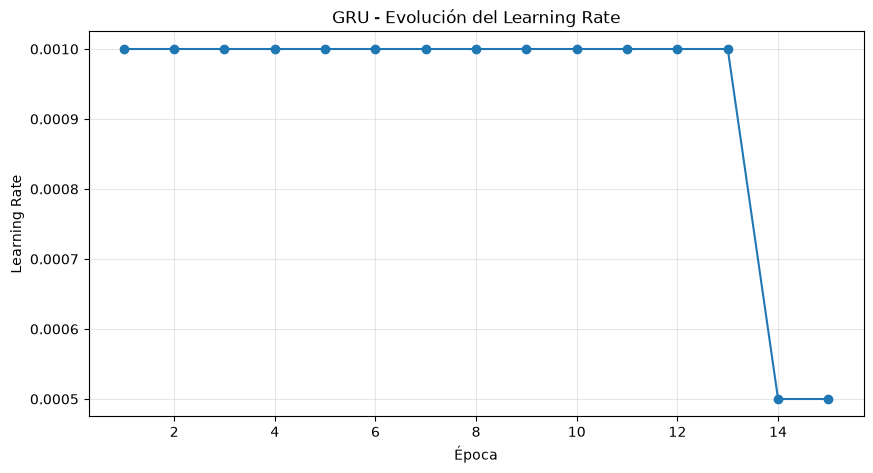

In [35]:
plt.figure(figsize=(10, 5))

plt.plot(
    epochs_gru,
    history_gru["lr"],
    marker="o"
)

plt.title("GRU - Evolución del Learning Rate")
plt.xlabel("Época")
plt.ylabel("Learning Rate")
plt.grid(alpha=0.3)

plt.show()

## 23. Evaluación del GRU sobre el conjunto de prueba

El modelo GRU se evalúa sobre el conjunto de prueba, que no fue utilizado durante el entrenamiento ni durante la selección del mejor modelo.

Se calculan Accuracy, Precision, Recall y F1-score para obtener una evaluación integral del clasificador.

In [37]:
y_true_gru, y_pred_gru = get_predictions(
    gru_model,
    test_loader
)

accuracy_gru = accuracy_score(
    y_true_gru,
    y_pred_gru
)

precision_gru = precision_score(
    y_true_gru,
    y_pred_gru,
    average="weighted",
    zero_division=0
)

recall_gru = recall_score(
    y_true_gru,
    y_pred_gru,
    average="weighted",
    zero_division=0
)

f1_gru = f1_score(
    y_true_gru,
    y_pred_gru,
    average="weighted",
    zero_division=0
)

print(f"Accuracy : {accuracy_gru:.4f}")
print(f"Precision: {precision_gru:.4f}")
print(f"Recall   : {recall_gru:.4f}")
print(f"F1-score : {f1_gru:.4f}")

Accuracy : 0.9894
Precision: 0.9894
Recall   : 0.9894
F1-score : 0.9894


## 24. Reporte de clasificación del GRU

Se analiza el rendimiento del GRU para cada una de las clases meteorológicas, permitiendo identificar posibles diferencias en la capacidad del modelo para reconocer condiciones frías, moderadas y cálidas.

In [38]:
print(
    classification_report(
        y_true_gru,
        y_pred_gru,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        Frío     0.9887    0.9923    0.9905     20668
    Moderado     0.9860    0.9843    0.9851     22517
      Cálido     0.9940    0.9922    0.9931     19751

    accuracy                         0.9894     62936
   macro avg     0.9895    0.9896    0.9896     62936
weighted avg     0.9894    0.9894    0.9894     62936



## 25. Matriz de confusión del GRU

La matriz de confusión permite identificar las predicciones correctas e incorrectas realizadas por el modelo para cada categoría meteorológica.

La diagonal representa las predicciones correctas, mientras que los valores fuera de la diagonal muestran las clases que fueron confundidas por el modelo.

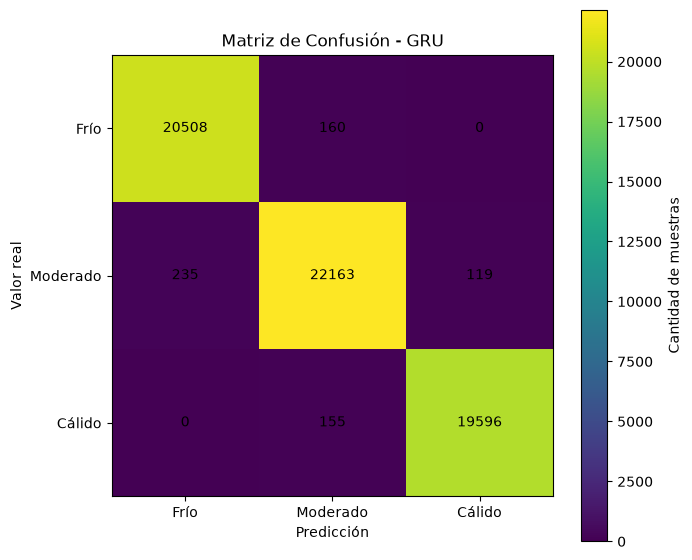

In [39]:
cm_gru = confusion_matrix(
    y_true_gru,
    y_pred_gru
)

plt.figure(figsize=(7, 6))

plt.imshow(cm_gru)

plt.title("Matriz de Confusión - GRU")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.xticks(
    range(len(class_names)),
    class_names
)

plt.yticks(
    range(len(class_names)),
    class_names
)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            cm_gru[i, j],
            ha="center",
            va="center"
        )

plt.colorbar(label="Cantidad de muestras")

plt.tight_layout()
plt.show()

## 26. Comparación de rendimiento entre LSTM y GRU

Se comparan los resultados obtenidos sobre el conjunto de prueba. Las métricas utilizadas son Accuracy, Precision, Recall y F1-score.

Esta comparación permite determinar cuál de las dos arquitecturas presenta el mejor rendimiento para la clasificación temporal de condiciones meteorológicas.

In [40]:
comparison = pd.DataFrame({
    "Modelo": ["LSTM", "GRU"],
    "Accuracy": [accuracy_lstm, accuracy_gru],
    "Precision": [precision_lstm, precision_gru],
    "Recall": [recall_lstm, recall_gru],
    "F1-score": [f1_lstm, f1_gru]
})

comparison

,Modelo,Accuracy,Precision,Recall,F1-score
0,LSTM,0.988941,0.988938,0.988941,0.988938
1,GRU,0.989370,0.989372,0.989370,0.989369


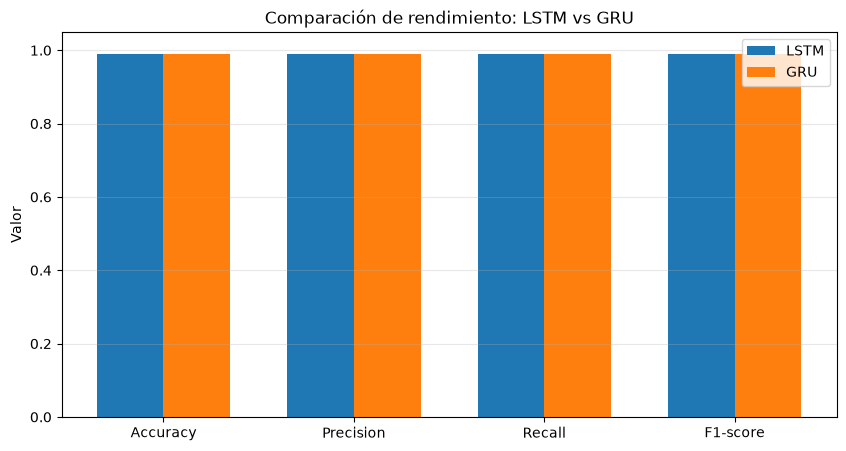

In [41]:
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width / 2,
    comparison.loc[0, metrics],
    width,
    label="LSTM"
)

plt.bar(
    x + width / 2,
    comparison.loc[1, metrics],
    width,
    label="GRU"
)

plt.xticks(x, metrics)
plt.ylim(0, 1.05)

plt.title("Comparación de rendimiento: LSTM vs GRU")
plt.ylabel("Valor")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

## 27. Comparación de las matrices de confusión

Las matrices de confusión de LSTM y GRU permiten comparar el comportamiento de ambos modelos para cada una de las categorías meteorológicas.

Se observa principalmente la cantidad de clasificaciones correctas y los errores producidos entre clases consecutivas.

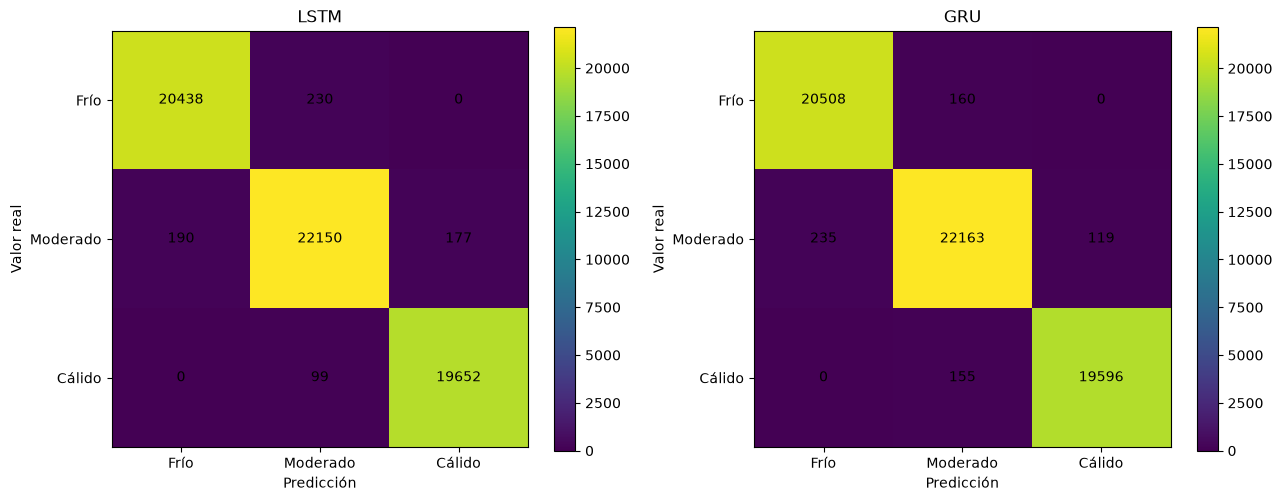

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# LSTM
im1 = axes[0].imshow(cm_lstm)

axes[0].set_title("LSTM")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Valor real")

axes[0].set_xticks(range(len(class_names)))
axes[0].set_xticklabels(class_names)

axes[0].set_yticks(range(len(class_names)))
axes[0].set_yticklabels(class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        axes[0].text(
            j, i,
            cm_lstm[i, j],
            ha="center",
            va="center"
        )

fig.colorbar(im1, ax=axes[0])

# GRU
im2 = axes[1].imshow(cm_gru)

axes[1].set_title("GRU")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Valor real")

axes[1].set_xticks(range(len(class_names)))
axes[1].set_xticklabels(class_names)

axes[1].set_yticks(range(len(class_names)))
axes[1].set_yticklabels(class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        axes[1].text(
            j, i,
            cm_gru[i, j],
            ha="center",
            va="center"
        )

fig.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

## 28. Análisis de resultados

Los dos modelos presentaron un rendimiento elevado en la clasificación de las condiciones meteorológicas. El modelo LSTM alcanzó una Accuracy de 98.89%, mientras que GRU obtuvo 98.94% sobre el conjunto de prueba.

El modelo GRU presentó una mejora de aproximadamente 0.05 puntos porcentuales respecto a LSTM. Aunque la diferencia es pequeña, ambos modelos demostraron una elevada capacidad para aprovechar la información temporal de las últimas 24 horas.

Las matrices de confusión muestran que la mayoría de las muestras fueron clasificadas correctamente. Los errores se concentran principalmente entre las categorías Frío y Moderado, y entre Moderado y Cálido. No se observaron confusiones directas entre Frío y Cálido en ninguno de los dos modelos.

El comportamiento observado indica que la clase Moderado presenta una mayor dificultad relativa de clasificación, debido a que representa una categoría intermedia entre los extremos de temperatura.

Durante el entrenamiento, ambos modelos utilizaron Dropout, Weight Decay, Early Stopping y un Learning Rate Scheduler. Estas técnicas permitieron controlar el proceso de aprendizaje y evitar un entrenamiento innecesariamente prolongado.

En términos generales, ambos modelos fueron capaces de aprender correctamente los patrones temporales presentes en los datos. GRU obtuvo el mejor resultado final de Accuracy, Precision, Recall y F1-score, por lo que se considera el modelo con mejor rendimiento para este experimento.

## 29. Conclusiones

1. Se desarrollaron dos modelos de redes neuronales recurrentes, LSTM y GRU, para clasificar condiciones meteorológicas a partir de secuencias temporales de 24 horas.

2. El preprocesamiento incluyó limpieza de valores inválidos, normalización de características y separación temporal de los conjuntos de entrenamiento, validación y prueba.

3. Las técnicas de optimización y regularización utilizadas fueron Adam, Learning Rate Scheduler, Dropout, Weight Decay, Gradient Clipping y Early Stopping.

4. El modelo LSTM obtuvo una Accuracy de 98.89%, mientras que GRU alcanzó 98.94% en el conjunto de prueba.

5. GRU presentó el mejor rendimiento global, aunque la diferencia respecto a LSTM fue reducida.

6. Las matrices de confusión demostraron que ambos modelos clasificaron correctamente la gran mayoría de las muestras y que los principales errores se produjeron entre categorías meteorológicas consecutivas.

7. El experimento demuestra que las arquitecturas recurrentes LSTM y GRU son capaces de aprovechar la información temporal de variables meteorológicas para realizar clasificación multiclase.

## 30. Configuración experimental

| Parámetro | Configuración |
|---|---|
| Dataset | Jena Climate |
| Registros originales | 420.551 |
| Registros después de limpieza | 420.531 |
| Características | 7 |
| Ventana temporal | 144 observaciones |
| Duración de la ventana | 24 horas |
| Clases | 3 |
| División | 70% entrenamiento / 15% validación / 15% prueba |
| Hidden Size | 64 |
| Capas recurrentes | 2 |
| Dropout | 0.3 |
| Batch Size | 64 |
| Optimizador | Adam |
| Learning Rate inicial | 0.001 |
| Weight Decay | 0.0001 |
| Scheduler | ReduceLROnPlateau |
| Factor del Scheduler | 0.5 |
| Paciencia del Scheduler | 2 |
| Early Stopping | Paciencia 4 |
| Gradient Clipping | 1.0 |
| Épocas máximas | 20 |
| Función de pérdida | Cross Entropy Loss |
| Semilla | 42 |